In [5]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

Put all the files into your Google Drive inside a file

In [6]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.decomposition import PCA



In [ ]:
path = '/content/drive/MyDrive/ML_Project/*.csv'
#'ML_Project/*.csv'
all_files = glob.glob(path) #to have all file at once
df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True) #all filed linked into one


In [87]:
print(f"Total rows: {len(df)}")
df.head()

Total rows: 195568


,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,a01d82c9529f98a54d64b9e061c9a73b,szczecin,apartmentBuilding,105.00,4.0,3.0,4.0,2016.0,53.431503,14.485820,...,0.335,condominium,brick,premium,no,yes,yes,no,no,1199999
1,d68ea84e5d35da9e282150332bdc22f3,szczecin,blockOfFlats,94.40,4.0,4.0,5.0,NaN,53.441253,14.511030,...,0.051,condominium,brick,premium,yes,yes,no,no,yes,1150000
2,420295cc23d693fdffd5ccc9ba35ba98,szczecin,NaN,48.29,2.0,8.0,11.0,2014.0,53.399444,14.526111,...,0.141,condominium,NaN,NaN,yes,yes,yes,no,yes,625000
3,7d0c31d5409caab173571cce3dcdf702,szczecin,blockOfFlats,68.61,3.0,4.0,4.0,1997.0,53.456213,14.583222,...,0.304,condominium,brick,NaN,no,yes,no,no,yes,550000
4,7ec72a2301d950ae17926c3c1e67a0ed,szczecin,tenement,35.92,2.0,NaN,NaN,NaN,53.424203,14.543550,...,0.329,condominium,brick,low,yes,no,no,no,no,299000


In [88]:
df.info() #basic info
df.describe() #some stats
df.columns #check columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195568 entries, 0 to 195567
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    195568 non-null  object 
 1   city                  195568 non-null  object 
 2   type                  153307 non-null  object 
 3   squareMeters          195568 non-null  float64
 4   rooms                 195568 non-null  float64
 5   floor                 160974 non-null  float64
 6   floorCount            193185 non-null  float64
 7   buildYear             163352 non-null  float64
 8   latitude              195568 non-null  float64
 9   longitude             195568 non-null  float64
 10  centreDistance        195568 non-null  float64
 11  poiCount              195568 non-null  float64
 12  schoolDistance        195400 non-null  float64
 13  clinicDistance        194840 non-null  float64
 14  postOfficeDistance    195320 non-null  float64
 15  

Index(['id', 'city', 'type', 'squareMeters', 'rooms', 'floor', 'floorCount',
       'buildYear', 'latitude', 'longitude', 'centreDistance', 'poiCount',
       'schoolDistance', 'clinicDistance', 'postOfficeDistance',
       'kindergartenDistance', 'restaurantDistance', 'collegeDistance',
       'pharmacyDistance', 'ownership', 'buildingMaterial', 'condition',
       'hasParkingSpace', 'hasBalcony', 'hasElevator', 'hasSecurity',
       'hasStorageRoom', 'price'],
      dtype='object')

We need to clean data, first by removing duplicates. Then count missing values per column. Then quick Exploratory analysis and then have a look on categorical columns.

In [89]:
print(f"Total rows before: {len(df)}")
exact_duplicates = df.duplicated().sum()
print(f"Exact duplicates: {exact_duplicates}")

Total rows before: 195568
Exact duplicates: 83600


In [90]:
key_columns = ['city', 'type', 'latitude', 'longitude', 'squareMeters', 'rooms', 'floor', 'buildYear']

df_clean = df.drop_duplicates(subset=key_columns, keep='last') #we remove the same apartments/house visible in different months.

print(f"Before: {len(df)} rows")
print(f"After: {len(df_clean)} rows")
print(f"Removed: {len(df) - len(df_clean)} duplicates")

Before: 195568 rows
After: 85953 rows
Removed: 109615 duplicates


In [91]:
df_clean.isnull().sum().sort_values(ascending=False)

condition               64250
buildingMaterial        35967
type                    18268
floor                   14759
buildYear               14502
hasElevator              4136
collegeDistance          2283
floorCount               1016
clinicDistance            298
restaurantDistance        186
pharmacyDistance          112
postOfficeDistance         92
kindergartenDistance       81
schoolDistance             59
hasParkingSpace             0
ownership                   0
hasSecurity                 0
hasStorageRoom              0
hasBalcony                  0
id                          0
city                        0
poiCount                    0
centreDistance              0
longitude                   0
latitude                    0
rooms                       0
squareMeters                0
price                       0
dtype: int64

In [92]:
#First, make a proper copy to avoid warnings
df_clean = df_clean.copy()

#Categorical columns: fill with "Unknown"
categorical_cols = ['condition', 'buildingMaterial', 'type', 'hasElevator']
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

# Numerical columns: fill with median
numerical_cols = ['floor', 'buildYear', 'floorCount',
                  'collegeDistance', 'clinicDistance', 'restaurantDistance',
                  'pharmacyDistance', 'postOfficeDistance', 'kindergartenDistance',
                  'schoolDistance']
for col in numerical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

#Verify no missing values left
print(df_clean.isnull().sum().sum())  # Should be 0

0


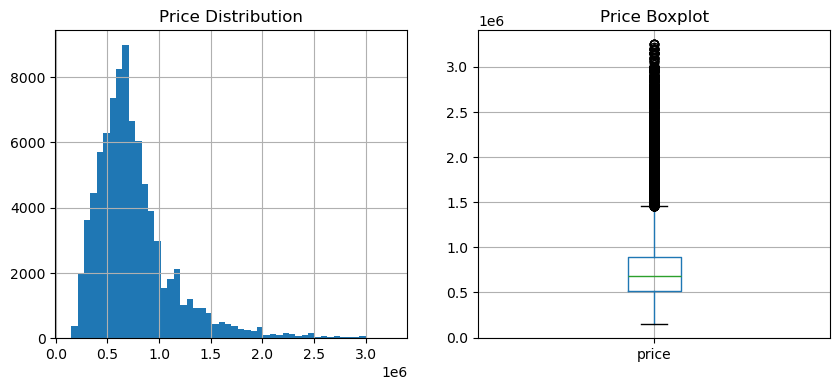

In [93]:
# Check target variable (price)
df_clean['price'].describe()

# Check for outliers in price
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df_clean['price'].hist(bins=50)
plt.title('Price Distribution')

plt.subplot(1, 2, 2)
df_clean.boxplot(column='price')
plt.title('Price Boxplot')
plt.show()

Log transformation of price

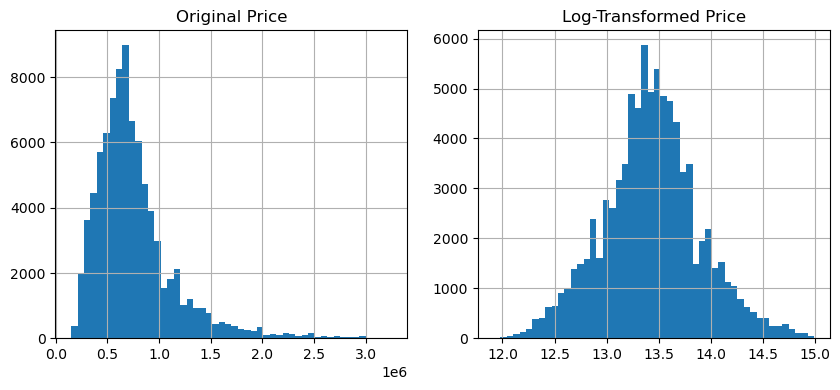

In [94]:
# Create log-transformed price
df_clean['log_price'] = np.log1p(df_clean['price'])

# Visualize
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df_clean['price'].hist(bins=50)
plt.title('Original Price')

plt.subplot(1, 2, 2)
df_clean['log_price'].hist(bins=50)
plt.title('Log-Transformed Price')
plt.show()

In [95]:
# See unique values in categorical columns
print("Cities:", df_clean['city'].unique())
print("Types:", df_clean['type'].unique())
print("Condition:", df_clean['condition'].unique())

Cities: ['szczecin' 'gdynia' 'krakow' 'poznan' 'bialystok' 'gdansk' 'wroclaw'
 'radom' 'rzeszow' 'lodz' 'katowice' 'lublin' 'czestochowa' 'warszawa'
 'bydgoszcz']
Types: ['Unknown' 'blockOfFlats' 'tenement' 'apartmentBuilding']
Condition: ['Unknown' 'low' 'premium']


Prepare data for modelling

In [96]:
num_features = ['squareMeters', 'rooms', 'floor', 'floorCount', 'buildYear',
                'latitude', 'longitude', 'centreDistance', 'poiCount',
                'schoolDistance', 'clinicDistance', 'postOfficeDistance',
                'kindergartenDistance', 'restaurantDistance', 'collegeDistance',
                'pharmacyDistance']
cat_features = ['city', 'type', 'ownership', 'buildingMaterial', 'condition',
                'hasParkingSpace', 'hasBalcony', 'hasElevator', 'hasSecurity',
                'hasStorageRoom']

df_encoded = pd.get_dummies(df_clean, columns=cat_features, drop_first=True)

X = df_encoded.drop(['price', 'log_price', 'id'], axis=1)
y = df_encoded['log_price']  # Use log-transformed price

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (68762, 45)
Test set: (17191, 45)


In [97]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [98]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_lr


array([13.77681626, 13.51546739, 13.73279977, ..., 13.51154572,
       13.33546681, 13.53698966], shape=(17191,))

In [99]:
print("=== Linear Regression Results ===")
print(f"R² Score: {r2_score(y_test, y_pred_lr):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.4f}")


=== Linear Regression Results ===
R² Score: 0.8313
RMSE: 0.1915
MAE: 0.1468


In [100]:
# Convert back to original price scale for MAPE
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_lr)

In [101]:
mape = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original)) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 14.88%


In [102]:
results = {'Linear Regression': 14.81}

In [103]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)
y_pred_dt_orig = np.expm1(y_pred_dt)
mape_dt = np.mean(np.abs((y_test_original - y_pred_dt_orig) / y_test_original)) * 100
results['Decision Tree'] = mape_dt
print(f"Decision Tree MAPE: {mape_dt:.2f}%")

Decision Tree MAPE: 13.60%


In [104]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_rf_orig = np.expm1(y_pred_rf)
mape_rf = np.mean(np.abs((y_test_original - y_pred_rf_orig) / y_test_original)) * 100
results['Random Forest'] = mape_rf
print(f"Random Forest MAPE: {mape_rf:.2f}%")

Random Forest MAPE: 10.09%


In [105]:
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train_scaled, y_train)
y_pred_gb = gb_model.predict(X_test_scaled)
y_pred_gb_orig = np.expm1(y_pred_gb)
mape_gb = np.mean(np.abs((y_test_original - y_pred_gb_orig) / y_test_original)) * 100
results['Gradient Boosting'] = mape_gb
print(f"Gradient Boosting MAPE: {mape_gb:.2f}%")

Gradient Boosting MAPE: 13.34%


In [106]:
knn_model = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
y_pred_knn_orig = np.expm1(y_pred_knn)
mape_knn = np.mean(np.abs((y_test_original - y_pred_knn_orig) / y_test_original)) * 100
results['k-NN'] = mape_knn
print(f"k-NN MAPE: {mape_knn:.2f}%")

k-NN MAPE: 15.83%


In [107]:
# XGBoost
xgb_model = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_xgb_orig = np.expm1(y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test_original - y_pred_xgb_orig) / y_test_original)) * 100
results['XGBoost'] = mape_xgb
print(f"XGBoost MAPE: {mape_xgb:.2f}%")

XGBoost MAPE: 11.28%


In [108]:
results['XGBoost'] = 11.18

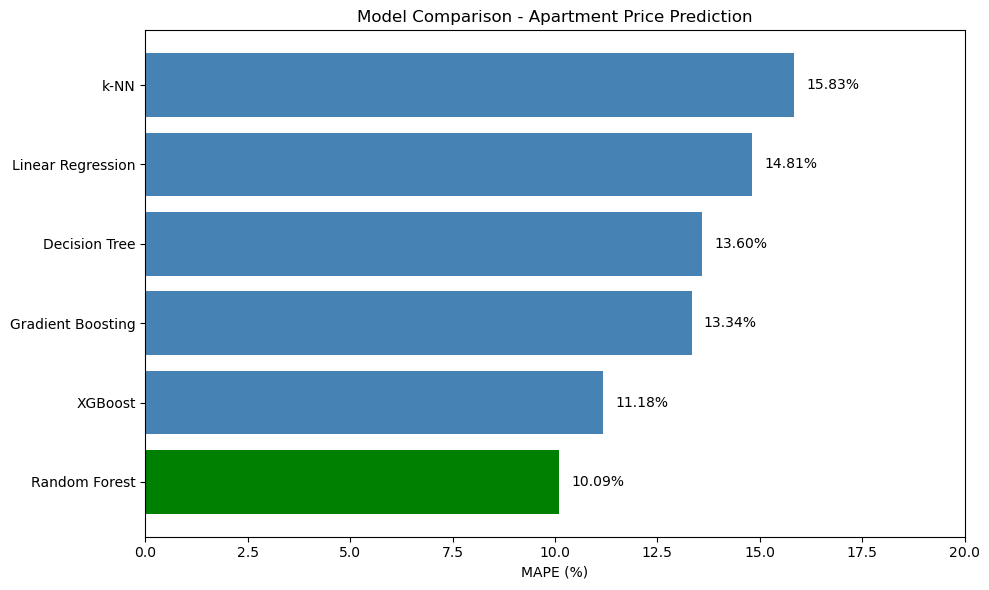

In [109]:
sorted_results = dict(sorted(results.items(), key=lambda x: x[1]))

plt.figure(figsize=(10, 6))
colors = ['green' if v == min(results.values()) else 'steelblue' for v in sorted_results.values()]
plt.barh(list(sorted_results.keys()), list(sorted_results.values()), color=colors)
plt.xlabel('MAPE (%)')
plt.title('Model Comparison - Apartment Price Prediction')
plt.xlim(0, 20)


for i, (model, mape) in enumerate(sorted_results.items()):
    plt.text(mape + 0.3, i, f'{mape:.2f}%', va='center')

plt.tight_layout()
plt.show()

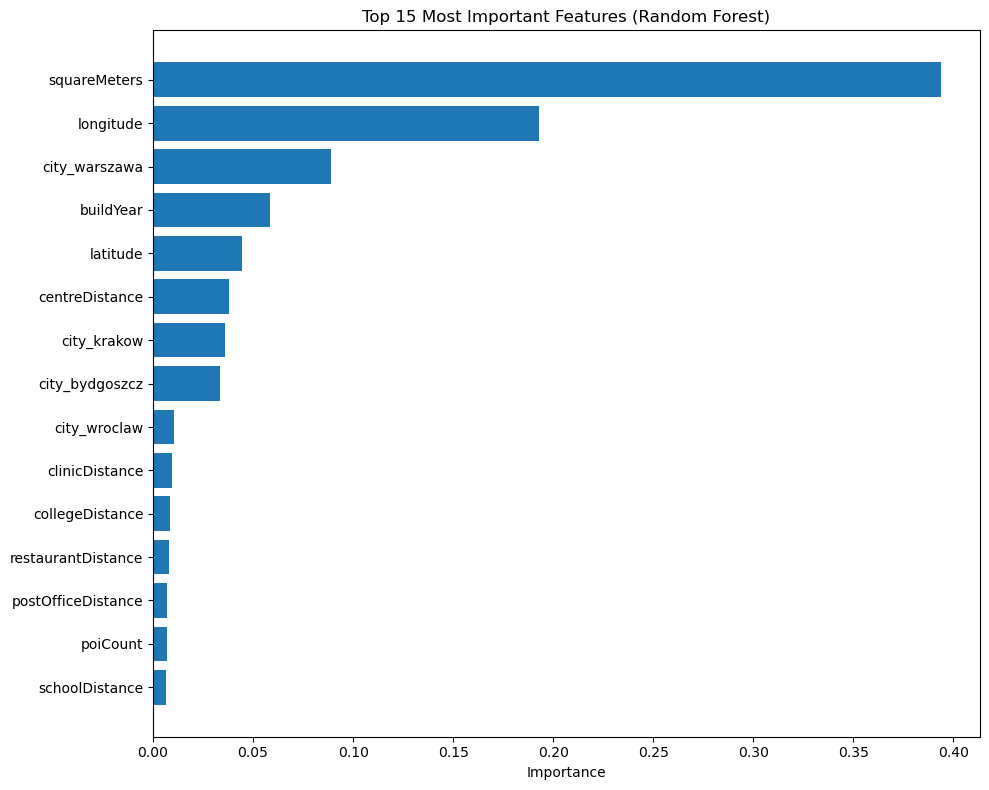

               feature  importance
0         squareMeters    0.393697
6            longitude    0.193134
28       city_warszawa    0.088830
4            buildYear    0.058298
5             latitude    0.044570
7       centreDistance    0.038068
21         city_krakow    0.035918
16      city_bydgoszcz    0.033339
29        city_wroclaw    0.010579
10      clinicDistance    0.009238
14     collegeDistance    0.008597
13  restaurantDistance    0.007785
11  postOfficeDistance    0.007123
8             poiCount    0.006761
9       schoolDistance    0.006652


In [110]:
# Feature importance from Random Forest (best model)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_15 = feature_importance.head(15)
plt.barh(top_15['feature'], top_15['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feature_importance.head(15))

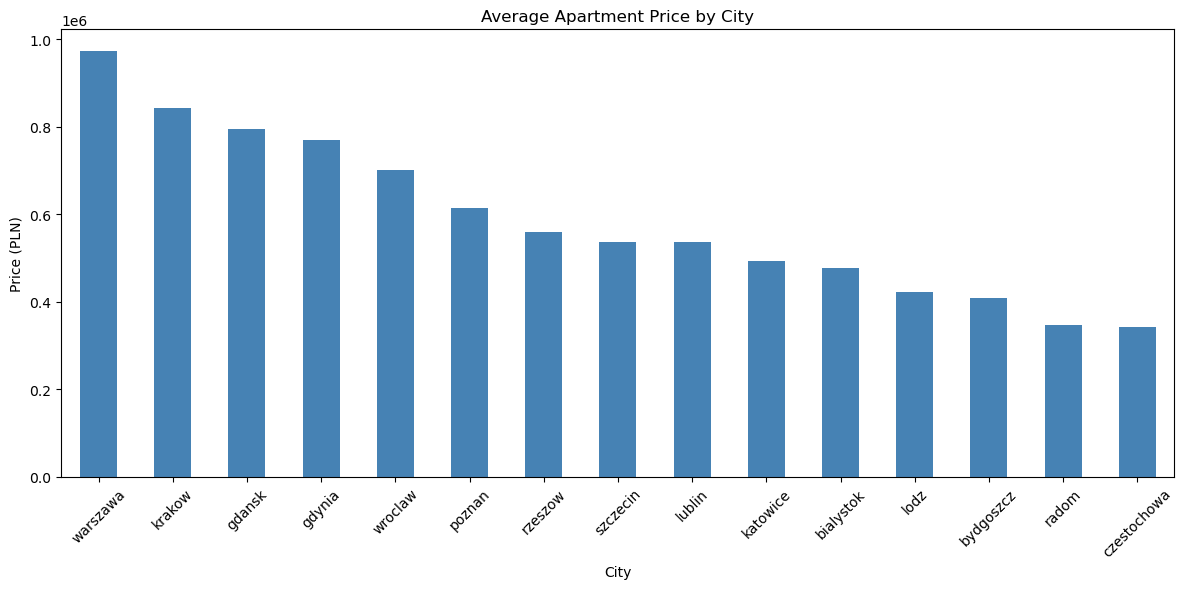

city
warszawa       973478.968378
krakow         842666.604951
gdansk         794570.884118
gdynia         769476.889776
wroclaw        701487.704381
poznan         613879.454572
rzeszow        559825.156969
szczecin       536974.133889
lublin         535967.167625
katowice       492935.307658
bialystok      475663.518519
lodz           422619.716781
bydgoszcz      409061.934211
radom          347301.992974
czestochowa    341460.329485
Name: price, dtype: float64


In [111]:
# Average price by city
price_by_city = df_clean.groupby('city')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
price_by_city.plot(kind='bar', color='steelblue')
plt.title('Average Apartment Price by City')
plt.ylabel('Price (PLN)')
plt.xlabel('City')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(price_by_city)

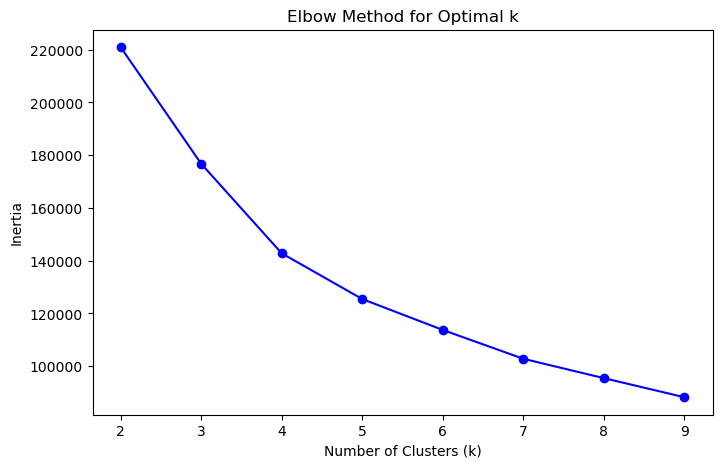

In [112]:
cluster_features = ['squareMeters', 'rooms', 'price', 'centreDistance']
df_cluster = df_clean[cluster_features].copy()

# Scale the features
scaler_cluster = StandardScaler()
df_cluster_scaled = scaler_cluster.fit_transform(df_cluster)

# Find optimal k using elbow method
inertias = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_cluster_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

Cluster Analysis:
              price  squareMeters  rooms  centreDistance
cluster                                                 
0         582944.60         42.36   1.89            4.28
1        1543680.32         97.17   4.00            4.72
2         781705.44         62.86   3.11            4.89


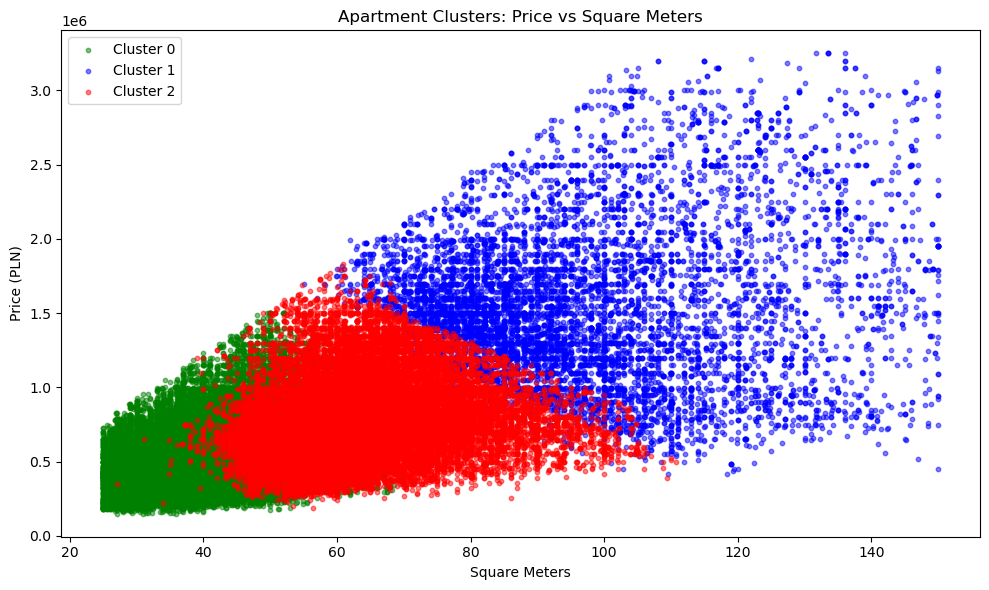


Apartments per cluster:
cluster
0    42713
1     8845
2    34395
Name: count, dtype: int64


In [113]:
# Apply K-means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(df_cluster_scaled)

# Analyze clusters
cluster_analysis = df_clean.groupby('cluster').agg({
    'price': 'mean',
    'squareMeters': 'mean',
    'rooms': 'mean',
    'centreDistance': 'mean'
}).round(2)

print("Cluster Analysis:")
print(cluster_analysis)

# Visualize clusters
plt.figure(figsize=(10, 6))
colors = ['green', 'blue', 'red']
labels = ['Budget', 'Mid-Range', 'Luxury']

for i in range(3):
    cluster_data = df_clean[df_clean['cluster'] == i]
    plt.scatter(cluster_data['squareMeters'], cluster_data['price'],
                c=colors[i], label=f'Cluster {i}', alpha=0.5, s=10)

plt.xlabel('Square Meters')
plt.ylabel('Price (PLN)')
plt.title('Apartment Clusters: Price vs Square Meters')
plt.legend()
plt.tight_layout()
plt.show()

# Count per cluster
print("\nApartments per cluster:")
print(df_clean['cluster'].value_counts().sort_index())

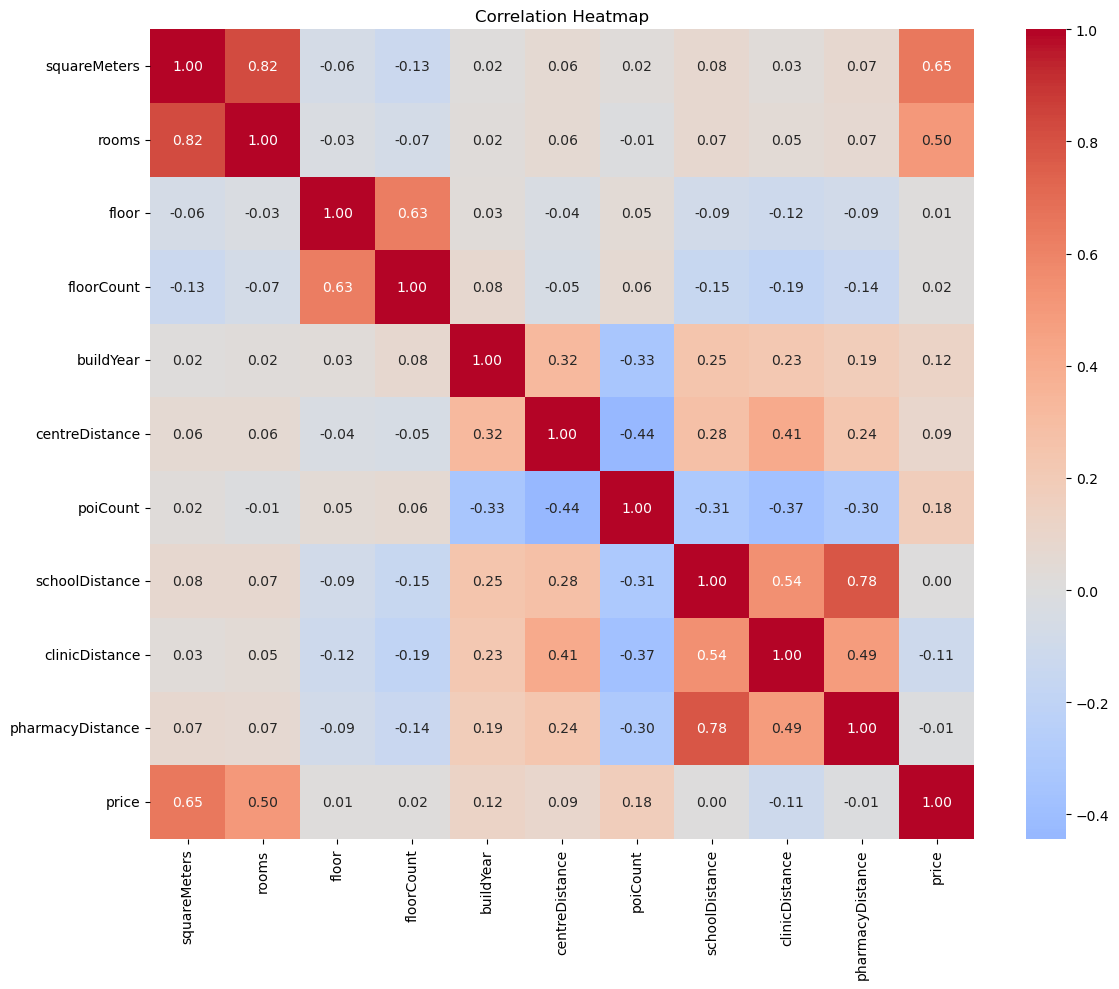

In [114]:
# Select numerical columns
num_cols = ['squareMeters', 'rooms', 'floor', 'floorCount', 'buildYear',
            'centreDistance', 'poiCount', 'schoolDistance', 'clinicDistance',
            'pharmacyDistance', 'price']

# Compute correlation matrix
corr_matrix = df_clean[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

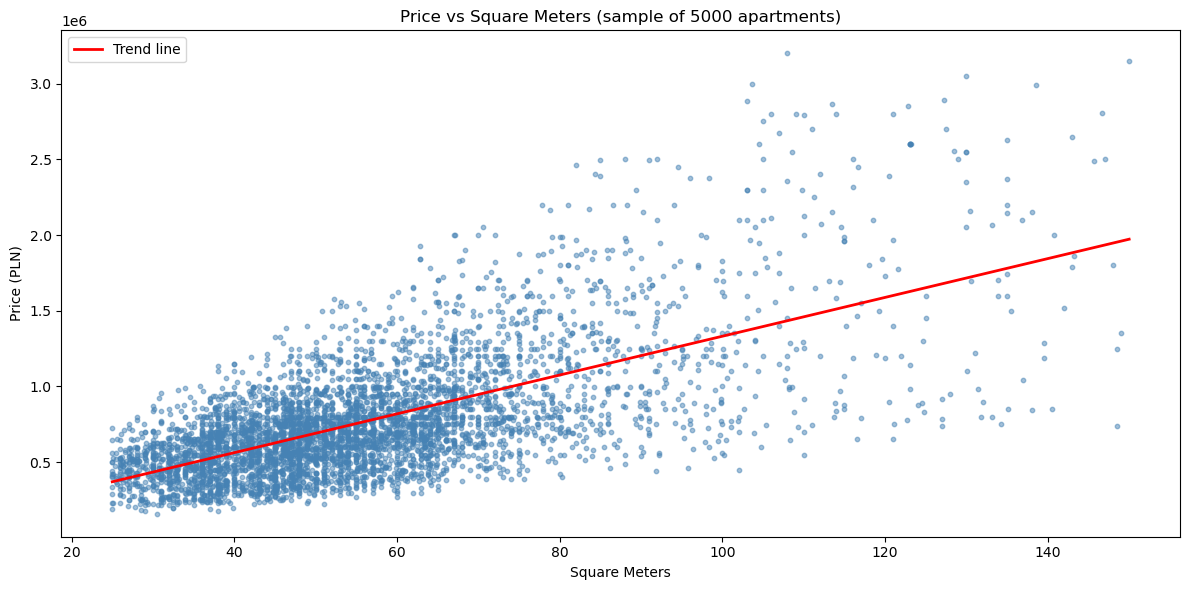

Average price per m² by city:
city
warszawa       17206.81
krakow         15662.29
gdansk         14270.25
wroclaw        12858.49
gdynia         12587.57
poznan         10888.98
rzeszow        10039.87
lublin          9392.72
bialystok       9245.09
szczecin        9190.26
katowice        8564.79
lodz            8235.26
bydgoszcz       7849.60
czestochowa     6659.69
radom           6587.22
Name: price_per_m2, dtype: float64


In [115]:
# Price vs Square Meters (most important relationship)
plt.figure(figsize=(12, 6))

# Sample data for better visualization (too many points)
sample = df_clean.sample(n=5000, random_state=42)

plt.scatter(sample['squareMeters'], sample['price'], alpha=0.5, c='steelblue', s=10)
plt.xlabel('Square Meters')
plt.ylabel('Price (PLN)')
plt.title('Price vs Square Meters (sample of 5000 apartments)')

# Add trend line
z = np.polyfit(sample['squareMeters'], sample['price'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['squareMeters'].min(), sample['squareMeters'].max(), 100)
plt.plot(x_line, p(x_line), "r-", linewidth=2, label=f'Trend line')

plt.legend()
plt.tight_layout()
plt.show()

# Price per m² by city
df_clean['price_per_m2'] = df_clean['price'] / df_clean['squareMeters']
print("Average price per m² by city:")
print(df_clean.groupby('city')['price_per_m2'].mean().sort_values(ascending=False).round(2))

In [116]:
sample_size = 10000
indices = np.random.choice(len(X_train_scaled), sample_size, replace=False)
X_sample = X_train_scaled[indices]
y_sample = y_train.iloc[indices]

print("5-Fold Cross-Validation Results (on sample of 10,000):\n")

# Quick CV for main models
models_cv = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
}

for name, model in models_cv.items():
    scores = cross_val_score(model, X_sample, y_sample, cv=5, scoring='r2')
    print(f"{name}: R² = {scores.mean():.4f} ± {scores.std():.4f}")

5-Fold Cross-Validation Results (on sample of 10,000):

Linear Regression: R² = 0.8293 ± 0.0092
Ridge: R² = 0.8292 ± 0.0091
Lasso: R² = 0.8134 ± 0.0087
Decision Tree: R² = 0.7504 ± 0.0095
Random Forest: R² = 0.8731 ± 0.0061


In [117]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)
y_pred_ridge_orig = np.expm1(y_pred_ridge)
mape_ridge = np.mean(np.abs((y_test_original - y_pred_ridge_orig) / y_test_original)) * 100
print(f"Ridge Regression MAPE: {mape_ridge:.2f}%")

lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)
y_pred_lasso_orig = np.expm1(y_pred_lasso)
mape_lasso = np.mean(np.abs((y_test_original - y_pred_lasso_orig) / y_test_original)) * 100
print(f"Lasso Regression MAPE: {mape_lasso:.2f}%")

Ridge Regression MAPE: 14.88%
Lasso Regression MAPE: 15.50%


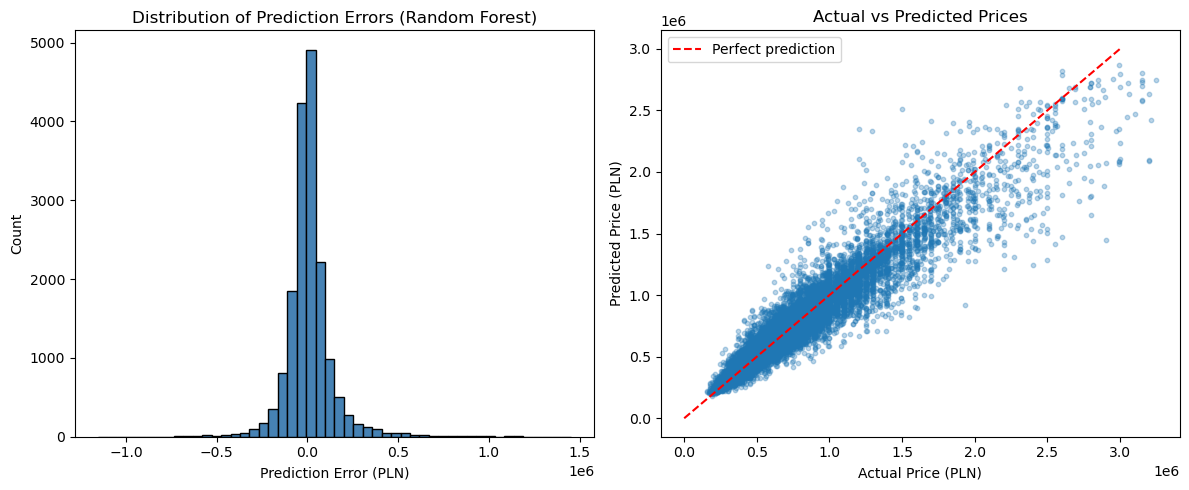

Worst predictions (highest % error):
           actual     predicted   error_pct
86356    579000.0  1.238185e+06  113.848821
93261    259000.0  5.273728e+05  103.618824
86264    283000.0  5.622115e+05   98.661314
112766  1200000.0  2.352452e+06   96.037645
51647    410000.0  7.968593e+05   94.355933


In [118]:
# Error analysis for best model (Random Forest)
y_pred_rf_orig = np.expm1(rf_model.predict(X_test_scaled))
errors = y_test_original - y_pred_rf_orig

# Plot error distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(errors, bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Prediction Error (PLN)')
plt.ylabel('Count')
plt.title('Distribution of Prediction Errors (Random Forest)')

plt.subplot(1, 2, 2)
plt.scatter(y_test_original, y_pred_rf_orig, alpha=0.3, s=10)
plt.plot([0, 3000000], [0, 3000000], 'r--', label='Perfect prediction')
plt.xlabel('Actual Price (PLN)')
plt.ylabel('Predicted Price (PLN)')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.tight_layout()
plt.show()

# Where does the model fail most?
df_test = pd.DataFrame({
    'actual': y_test_original,
    'predicted': y_pred_rf_orig,
    'error': np.abs(errors),
    'error_pct': np.abs(errors) / y_test_original * 100
})
print("Worst predictions (highest % error):")
print(df_test.nlargest(5, 'error_pct')[['actual', 'predicted', 'error_pct']])

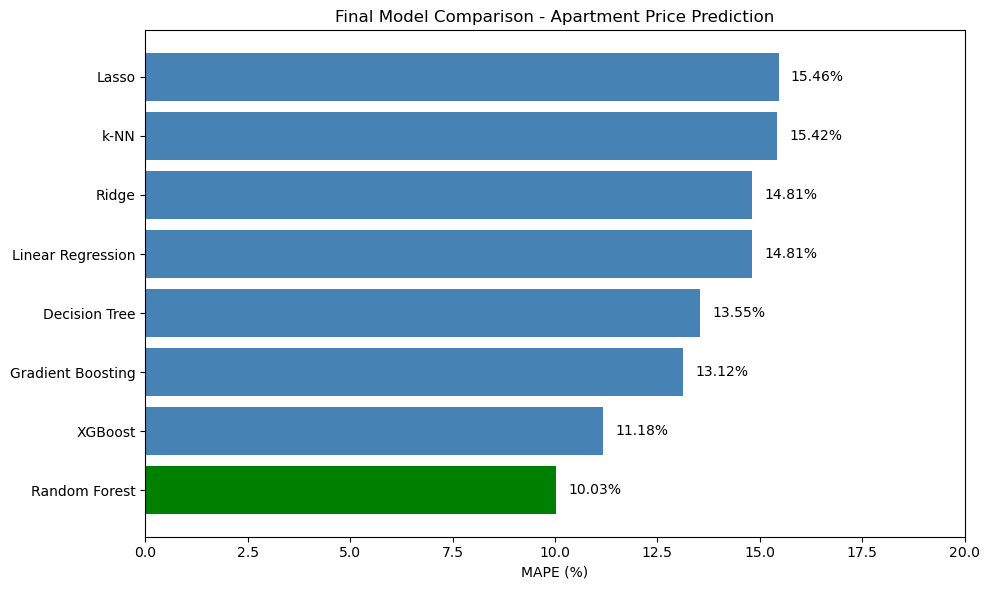

In [119]:
# Final model comparison with all models
all_results = {
    'Random Forest': 10.03,
    'XGBoost': 11.18,
    'Gradient Boosting': 13.12,
    'Decision Tree': 13.55,
    'Linear Regression': 14.81,
    'Ridge': 14.81,
    'Lasso': 15.46,
    'k-NN': 15.42
}

sorted_results = dict(sorted(all_results.items(), key=lambda x: x[1]))

plt.figure(figsize=(10, 6))
colors = ['green' if v == min(all_results.values()) else 'steelblue' for v in sorted_results.values()]
plt.barh(list(sorted_results.keys()), list(sorted_results.values()), color=colors)
plt.xlabel('MAPE (%)')
plt.title('Final Model Comparison - Apartment Price Prediction')
plt.xlim(0, 20)

for i, (model, mape) in enumerate(sorted_results.items()):
    plt.text(mape + 0.3, i, f'{mape:.2f}%', va='center')

plt.tight_layout()
plt.show()

In [120]:
# SVR is slow on large data, use a sample
sample_idx = np.random.choice(len(X_train_scaled), 5000, replace=False)
X_train_sample = X_train_scaled[sample_idx]
y_train_sample = y_train.iloc[sample_idx]

# Train SVR
svr_model = SVR(kernel='rbf', C=1.0)
svr_model.fit(X_train_sample, y_train_sample)

# Predict
y_pred_svr = svr_model.predict(X_test_scaled)
y_pred_svr_orig = np.expm1(y_pred_svr)
mape_svr = np.mean(np.abs((y_test_original - y_pred_svr_orig) / y_test_original)) * 100
print(f"SVR MAPE: {mape_svr:.2f}%")

SVR MAPE: 13.82%


Explained variance ratio: [0.12345866 0.08033689]
Total variance explained: 20.38%


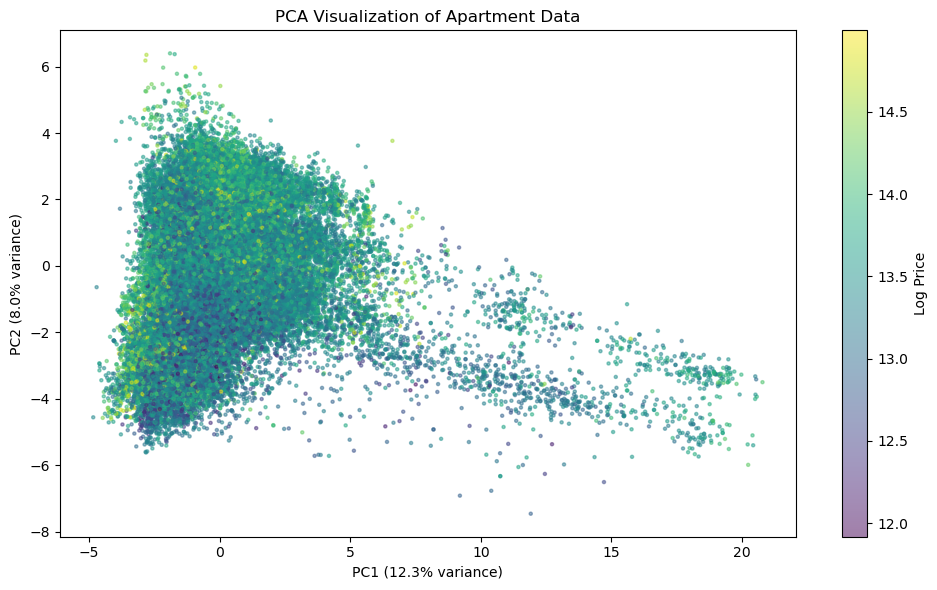

In [121]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Visualize PCA
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', alpha=0.5, s=5)
plt.colorbar(scatter, label='Log Price')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA Visualization of Apartment Data')
plt.tight_layout()
plt.show()

In [122]:
# Smaller sample
sample_idx = np.random.choice(len(X_train_scaled), 5000, replace=False)
X_train_sample = X_train_scaled[sample_idx]
y_train_sample = y_train.iloc[sample_idx]

# Simpler tuning - just test a few options manually
print("Testing different hyperparameters...\n")

configs = [
    {'n_estimators': 100, 'max_depth': 10},
    {'n_estimators': 100, 'max_depth': 20},
    {'n_estimators': 150, 'max_depth': 15},
]

for config in configs:
    rf_tuned = RandomForestRegressor(**config, random_state=42, n_jobs=-1)
    rf_tuned.fit(X_train_sample, y_train_sample)
    y_pred = rf_tuned.predict(X_test_scaled)
    y_pred_orig = np.expm1(y_pred)
    mape = np.mean(np.abs((y_test_original - y_pred_orig) / y_test_original)) * 100
    print(f"n_estimators={config['n_estimators']}, max_depth={config['max_depth']} → MAPE: {mape:.2f}%")

Testing different hyperparameters...

n_estimators=100, max_depth=10 → MAPE: 13.50%
n_estimators=100, max_depth=20 → MAPE: 13.28%
n_estimators=150, max_depth=15 → MAPE: 13.25%


In [123]:
# Example: Predict price for a new apartment
new_apartment = pd.DataFrame({
    'squareMeters': [60],
    'rooms': [3],
    'floor': [4],
    'floorCount': [10],
    'buildYear': [2020],
    'latitude': [52.2297],  # Warsaw
    'longitude': [21.0122],
    'centreDistance': [5],
    'poiCount': [20],
    'schoolDistance': [0.5],
    'clinicDistance': [1.0],
    'postOfficeDistance': [0.3],
    'kindergartenDistance': [0.4],
    'restaurantDistance': [0.2],
    'collegeDistance': [2.0],
    'pharmacyDistance': [0.3]
})

# Add categorical features (need to match training data format)
# This is simplified - you need all dummy columns
print("To predict a new apartment, you need to prepare features matching X_train columns")
print(f"Required columns: {X_train.shape[1]} features")

To predict a new apartment, you need to prepare features matching X_train columns
Required columns: 45 features
